# 04 — RFM: đổi đối tượng từ khách hàng sang sản phẩm

**RFM khách hàng — không làm được, cùng lý do đã nêu ở `03_cohort.ipynb`:**
không còn khoá định danh khách hàng nào sau khi loại PII ở Bước 1 (chủ đích,
không phải thiếu sót). Recency/Frequency/Monetary theo đúng định nghĩa gốc 
đều cần biết "khách nào" mua — không có cột nào thay được.

**Hướng đi:** áp dụng kỹ thuật RFM cho **sản phẩm** thay vì khách hàng — đây
là cách dùng RFM khá phổ biến trong merchandising thực tế (ưu tiên sản phẩm
nào cần đẩy mạnh, sản phẩm nào nên dừng nhập): `Recency` = số ngày kể từ lần
bán gần nhất, `Frequency` = số lần bán được, `Monetary` = tổng doanh thu.


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect("../data/clean/lazada.duckdb", read_only=True)

sales = con.execute("""
    SELECT product_code, order_date, (unitPrice - sellerDiscountTotal) AS revenue
    FROM fact_order_item_customer
    WHERE is_completed
""").df()
sales["order_date"] = pd.to_datetime(sales["order_date"])

SNAPSHOT = sales["order_date"].max()
print(f"Ngày mốc (snapshot) = ngày giao dịch cuối cùng trong dữ liệu: {SNAPSHOT.date()}")

rfm = sales.groupby("product_code").agg(
    last_sale=("order_date", "max"),
    frequency=("order_date", "count"),
    monetary=("revenue", "sum"),
)
rfm["recency_days"] = (SNAPSHOT - rfm["last_sale"]).dt.days
print(f"{len(rfm)} / 196 mã có ít nhất 1 đơn hoàn tất")
rfm.describe().round(0)


Ngày mốc (snapshot) = ngày giao dịch cuối cùng trong dữ liệu: 2023-01-27
192 / 196 mã có ít nhất 1 đơn hoàn tất


,last_sale,frequency,monetary,recency_days
count,192,192.0,192.0,192.0
mean,2021-08-30 07:37:30,85.0,4273972.0,515.0
min,2021-01-01 00:00:00,1.0,0.0,0.0
25%,2021-05-27 12:00:00,4.0,111156.0,452.0
50%,2021-09-02 12:00:00,12.0,401918.0,512.0
75%,2021-10-31 12:00:00,58.0,1983144.0,610.0
max,2023-01-27 00:00:00,4224.0,233014626.0,756.0
std,NaN,331.0,18036791.0,134.0


**Chỗ dễ sai — quan trọng nhất của cả notebook này:** RFM vốn được thiết kế
cho một **doanh nghiệp đang hoạt động**, `Recency` thấp (mới bán gần đây) là
tín hiệu tốt cần trân trọng, và hành động thường là "chăm sóc lại". Nhưng
shop trong dữ liệu này **đã ngừng hoạt động** ở thời điểm snapshot (thấy rõ ở
`01_seasonality.ipynb`: gần như không còn đơn từ 04/2022). Vì vậy
`Recency` ở đây gần như tương đương "sản phẩm nào sống sót lâu nhất trước
khi shop đóng cửa" — vẫn có giá trị đọc lại lịch sử, nhưng **không thể dùng
để ra quyết định marketing/tồn kho cho hiện tại** như RFM thường được dùng.


In [2]:
# Chia ngu phan vi (quintile), diem 1-5. Recency: gan day hon = diem cao hon
# (nen dao nguoc thu tu). Dung rank(method="first") truoc qcut de tranh loi
# "Bin edges must be unique" khi nhieu san pham co cung Frequency (vd. deu
# ban 1-2 lan).
rfm["R"] = pd.qcut(rfm["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]


def segment(row):
    if row["RFM_score"] >= 13:
        return "Sao (Star)"
    if row["RFM_score"] >= 10:
        return "Tiềm năng"
    if row["RFM_score"] >= 7:
        return "Cần chú ý"
    return "Mờ nhạt / đã chết"


rfm["segment"] = rfm.apply(segment, axis=1)
rfm["segment"].value_counts()


segment
Tiềm năng            59
Cần chú ý            58
Mờ nhạt / đã chết    45
Sao (Star)           30
Name: count, dtype: int64

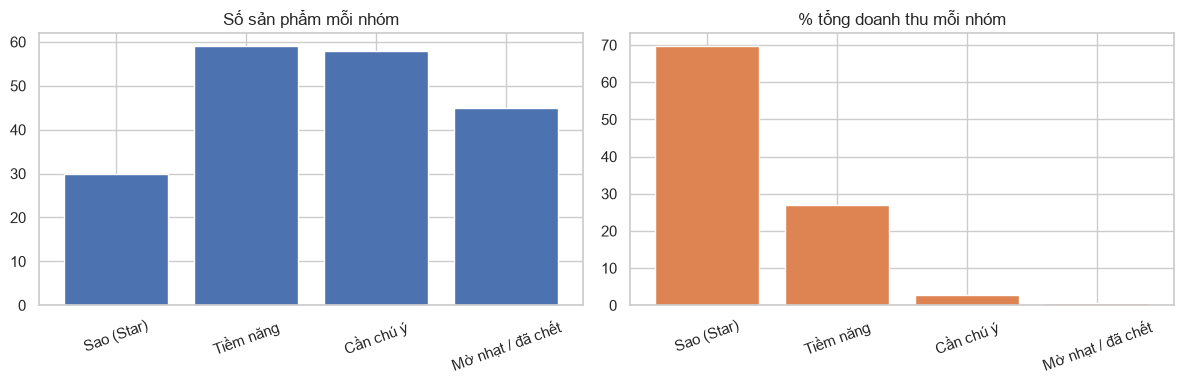

,so_san_pham,tong_doanh_thu,ty_trong_doanh_thu_pct
segment,,,
Sao (Star),30,571647968.0,69.7
Tiềm năng,59,220790394.0,26.9
Cần chú ý,58,23578250.0,2.9
Mờ nhạt / đã chết,45,4585986.0,0.6


In [3]:
seg_order = ["Sao (Star)", "Tiềm năng", "Cần chú ý", "Mờ nhạt / đã chết"]
seg_summary = rfm.groupby("segment").agg(
    so_san_pham=("monetary", "count"),
    tong_doanh_thu=("monetary", "sum"),
).reindex(seg_order)
seg_summary["ty_trong_doanh_thu_pct"] = 100 * seg_summary["tong_doanh_thu"] / seg_summary["tong_doanh_thu"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(seg_summary.index, seg_summary["so_san_pham"], color="#4C72B0")
axes[0].set_title("Số sản phẩm mỗi nhóm")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(seg_summary.index, seg_summary["ty_trong_doanh_thu_pct"], color="#DD8452")
axes[1].set_title("% tổng doanh thu mỗi nhóm")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

seg_summary.round(1)


**Đọc kết quả:** 30/192 sản phẩm (15,6%) rơi vào nhóm "Sao" nhưng chiếm tới
**69,7%** tổng doanh thu — khớp với quy luật Pareto đã thấy nhiều lần trong
project (SHRTT01 chiếm phần lớn doanh thu ở Phân tích 2/3). Nhóm "Mờ nhạt/đã
chết" (45 sản phẩm, 23,4% danh mục) chỉ đóng góp 0,6% doanh thu — đây là ứng
viên rõ ràng nhất để **dừng nhập/loại khỏi danh mục** nếu shop còn hoạt động.

**Chỗ dễ sai:** đừng đọc "Sao" theo nghĩa RFM gốc là "khách hàng tốt nhất,
cần chăm sóc giữ chân" — ở đây "Sao" chỉ có nghĩa "sản phẩm bán chạy, bán
đều, bán gần đây nhất trước khi shop đóng cửa". Hành động gợi ý đúng là
"ưu tiên nhập lại/đẩy mạnh nếu mở lại kinh doanh", không phải các hành động
CRM (email chăm sóc, ưu đãi giữ chân...) mà RFM khách hàng thường dẫn tới.


## Kết luận

RFM áp cho sản phẩm xác nhận định lượng quy luật Pareto trong toàn bộ danh
mục: 30/192 sản phẩm (15,6%) tạo ra 69,7% doanh thu; 45 sản phẩm (23,4%) gần
như không đáng kể (0,6% doanh thu). Đây là bằng chứng có hệ thống, không chỉ
dựa vào 1 sản phẩm nổi bật (SHRTT01) như các phân tích trước — dù SHRTT01
vẫn là sản phẩm dẫn đầu rõ rệt trong chính nhóm "Sao" này.

## Giới hạn

Đây là RFM **sản phẩm**, không phải RFM **khách hàng** — không trả lời được
câu hỏi gốc về phân khúc khách hàng, đúng giới hạn đã nêu ở đầu notebook và
lặp lại ở `03_cohort.ipynb`. `Recency` mất phần lớn ý nghĩa hành động vì shop
đã ngừng hoạt động (đã nêu ở trên) — chỉ `Frequency` và `Monetary` còn giữ
nguyên giá trị diễn giải như RFM truyền thống. Ngưỡng chia nhóm (13, 10, 7
điểm) là quy ước chọn thủ công, không có kiểm định thống kê đứng sau — đổi
ngưỡng sẽ đổi số sản phẩm mỗi nhóm, cần nói rõ đây là lựa chọn phân loại, không
phải ranh giới tự nhiên trong dữ liệu.
